In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Carga de datos (asumiendo que descargaste el csv de Kaggle)
df = pd.read_csv('/Users/santiago/Desktop/Python projects/Credit_Risk/credit_risk_dataset.csv')

# 1. Limpieza inicial: Manejo de nulos y outliers
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].mean(), inplace=True)

# Eliminar outliers financieros ilógicos (ej. edad > 100 años)
df = df[df['person_age'] < 100]

print(f"Dataset limpio con {df.shape[0]} registros.")

Dataset limpio con 32576 registros.


/var/folders/w6/w06s4ql12rj40xcmyrsjrmcw0000gn/T/ipykernel_37441/2943122310.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
/var/folders/w6/w06s4ql12rj40xcmyrsjrmcw0000gn/T/ipykernel_37441/2943122310.py:12: ChainedAssignmentError: A value is being set

In [3]:
# Creación de Ratios Financieros
df['debt_to_income_ratio'] = df['loan_amnt'] / df['person_income']
df['loan_to_age_ratio'] = df['loan_amnt'] / df['person_age']

# Codificación de variables categóricas (One-Hot Encoding)
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'loan_grade'], drop_first=True)

# Convertir la variable de historial previo a binario
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Definir X e y
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Configuración del modelo
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=4, # Para manejar el desbalance (aprox 4 pagadores por cada 1 default)
    random_state=42
)

model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5094
           1       0.81      0.81      0.81      1422

    accuracy                           0.92      6516
   macro avg       0.88      0.88      0.88      6516
weighted avg       0.92      0.92      0.92      6516

ROC-AUC Score: 0.9508


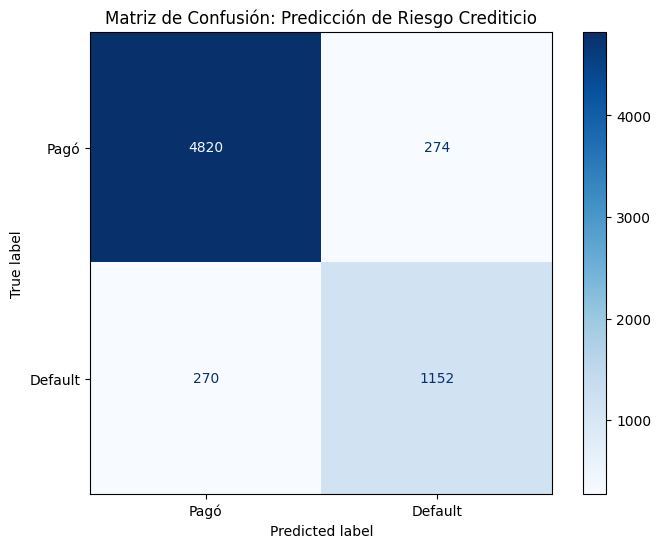

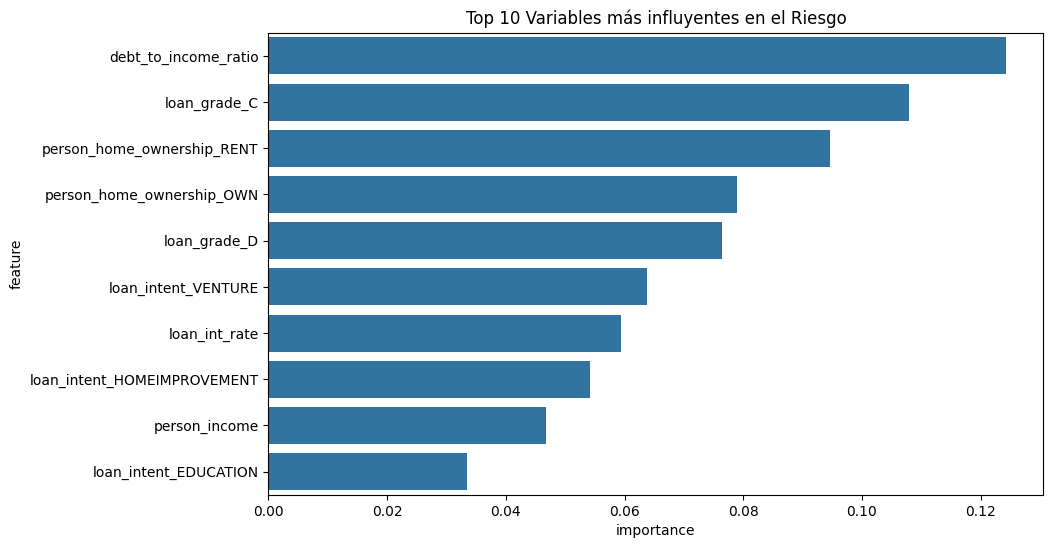

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

# Visualizar la Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['Pagó', 'Default'], cmap='Blues', ax=ax)
plt.title('Matriz de Confusión: Predicción de Riesgo Crediticio')
plt.show()

# Ver la importancia de las variables (Feature Importance)
# Esto te dice qué columnas "pesaron" más para el modelo
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances.head(10))
plt.title('Top 10 Variables más influyentes en el Riesgo')
plt.show()

/var/folders/w6/w06s4ql12rj40xcmyrsjrmcw0000gn/T/ipykernel_37441/1089221282.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])


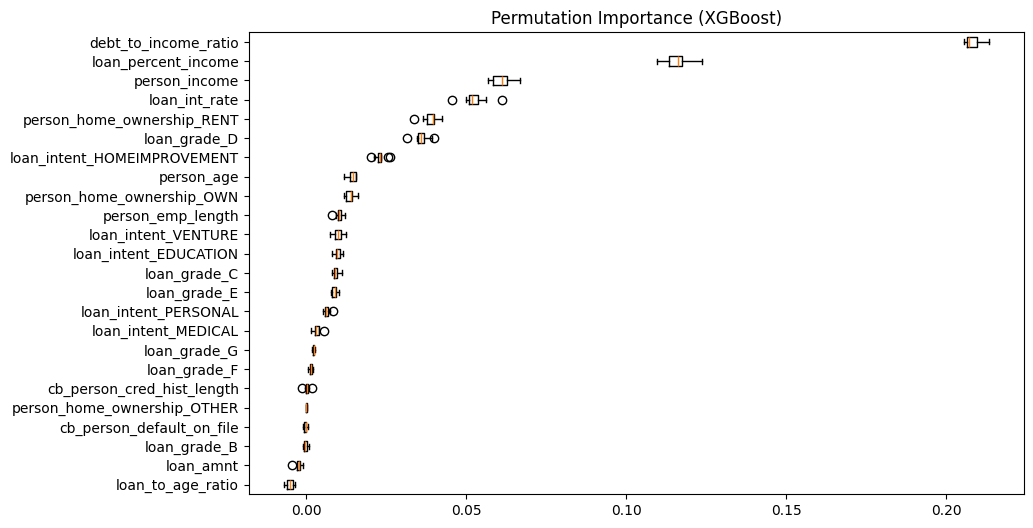

In [9]:
# Alternativa profesional que sí funciona en Python 3.14
from sklearn.inspection import permutation_importance

# Calculamos la importancia por permutación
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Graficamos
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
plt.title("Permutation Importance (XGBoost)")
plt.show()